In [1]:
REPO = '../'
RESULT_TABLE = f'{REPO}/data/table'
RESULT_OBJ = f'{REPO}/data/object'
FIGURE_FOLDER= f'{REPO}/data/figure'
SETTING_FOLDER = f'{REPO}/data/setting'
EXTERNAL_DATA=f'{REPO}/data/external'


import sys
sys.path.append(REPO)
from settings import COLOR_PAlETTE
from utils.visual import *
from utils.statsTest import lmTest

import scipy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scPipe as sp
import scanpy as sc
import seaborn as sns
import warnings
import commentjson
### Additional Colormap
with open(f'{SETTING_FOLDER}/ColorMap.json','r') as f:
    colormap = commentjson.load(f)
COLOR_PAlETTE.update(colormap)
plt.style.use(f'{REPO}/paper.mplstyle')
warnings.filterwarnings("ignore")
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [3]:
Celltype = 'Tumor'
adata = sc.read(f'{RESULT_OBJ}/gex_all.h5ad')
obs = pd.read_csv(f"{RESULT_TABLE}/MPs/{Celltype}/Annotation.csv",index_col=0)
sample_meta = pd.read_excel(f'{RESULT_TABLE}/Supplementary Table 1.xlsx',index_col=0).replace(np.nan,'N/A')

adata = adata[adata.obs.index.isin(obs.index),:]
adata.obs['Cellstate'] = obs.loc[adata.obs.index,'Cellstate']
adata.obs = adata.obs.merge(sample_meta,left_on='Sample',right_on='CCG_ID')
print(f'{adata.obs.shape[0]:,} {Celltype} cells')
adata.obs['Cellstate'].value_counts()

65,206 Tumor cells


Tumor.ER-I                   30900
Tumor.ER-II                  11408
Tumor.Cell_Cycle             10975
Tumor.Interferon/MHCII(I)     5033
Tumor.EMT-II                  4158
Tumor.EMT-III                 2732
Name: Cellstate, dtype: int64

In [4]:
ra_prop = (
    adata.obs.
    groupby(['Patient','Timepoint','BestResponse'])['Cellstate'].
    value_counts(normalize=True).
    rename('Pct').
    reset_index()
)

In [5]:
ra_prop

,Patient,Timepoint,BestResponse,Cellstate,Pct
0,P01,Baseline,favorable response\n(RCB 0-I),Tumor.EMT-II,0.371276
1,P01,Baseline,favorable response\n(RCB 0-I),Tumor.Cell_Cycle,0.360620
2,P01,Baseline,favorable response\n(RCB 0-I),Tumor.ER-II,0.208767
3,P01,Baseline,favorable response\n(RCB 0-I),Tumor.ER-I,0.023735
4,P01,Baseline,favorable response\n(RCB 0-I),Tumor.EMT-III,0.021070
...,...,...,...,...,...
181,P26,Baseline,unfavorable response\n(RCB II-III),Tumor.Cell_Cycle,0.468867
182,P26,Baseline,unfavorable response\n(RCB II-III),Tumor.ER-II,0.009187
183,P26,Baseline,unfavorable response\n(RCB II-III),Tumor.EMT-II,0.002722
184,P26,Baseline,unfavorable response\n(RCB II-III),Tumor.Interferon/MHCII(I),0.000340


## Explore the trend by percentages

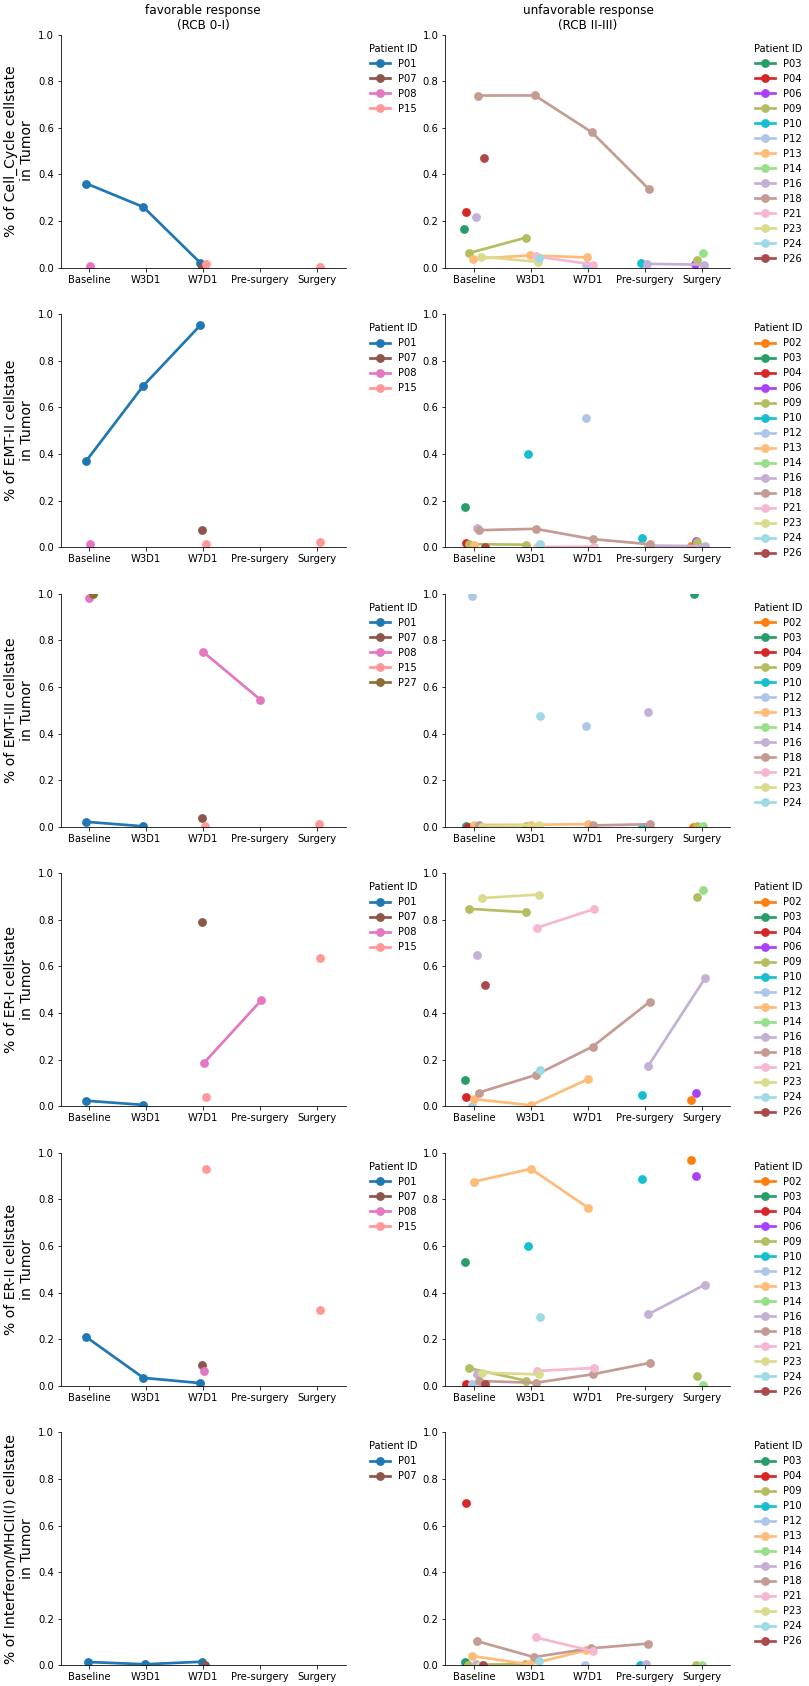

In [7]:
fig,axs = plt.subplots(ra_prop.Cellstate.nunique(),2,figsize=(12, 5*ra_prop.Cellstate.nunique()))
for i,(cellstate,data) in enumerate(ra_prop.groupby('Cellstate')):
    # Create the point plot
    ax=axs[i,0]
    sns.pointplot(
        data=data.loc[(data.BestResponse=='favorable response\n(RCB 0-I)'),:],
        x='Timepoint',
        y='Pct',
        order=['Baseline','W3D1','W7D1','Pre-surgery','Surgery'],
        hue='Patient',
        palette=COLOR_PAlETTE['Patient'],
        dodge=True,
        ax=ax
    )
    
    # Add labels and title
    if i ==0:
        ax.set_title('favorable response\n(RCB 0-I)')
    ax.set_ylabel(f'% of {cellstate.split(".")[1]} cellstate\nin {Celltype}', fontsize=14)
    ax.set_xlabel('')
    ax.set_ylim(0,1)
    ax.legend(title='Patient ID', bbox_to_anchor=(1.05, 1), loc='upper left'
             )
    # Create the point plot
    ax=axs[i,1]
    sns.pointplot(
        data=data.loc[(data.BestResponse=='unfavorable response\n(RCB II-III)'),:],
        x='Timepoint',
        y='Pct',
        order=['Baseline','W3D1','W7D1','Pre-surgery','Surgery'],
        hue='Patient',
         palette=COLOR_PAlETTE['Patient'],
        dodge=True,
        ax=ax
    )
    
    # Add labels and title
    if i ==0:
        ax.set_title('unfavorable response\n(RCB II-III)')
    ax.set_ylabel('')
    ax.set_xlabel('')
    ax.set_ylim(0,1)
    ax.legend(title='Patient ID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.subplots_adjust(wspace=.35)
fig.savefig(f'{FIGURE_FOLDER}/{Celltype}_MP_Distribution_By_Patient_R_and_NR.pdf',dpi=150,bbox_inches='tight')